### Importing Libraries

In [1]:
import os
import gc
import torch
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('display.max_columns', None)

### Creating data manifest and splitting data

In [3]:
%cd ..

d:\Projects\BrainTumor-Classification-Segmentation


In [4]:
train_image = []
train_mask = []

root_dir = f'{os.getcwd()}/Data/segmentation_task/train'
image_dir = f'{root_dir}/images'
mask_dir = f'{root_dir}/masks'

for image in os.listdir(image_dir):
    mask = image.replace('.jpg', '.png')
    mask_path = f'{mask_dir}/{mask}'
    if os.path.exists(mask_path):
        train_image.append(f'{image_dir}/{image}')
        train_mask.append(mask_path)
    else:
        print(f"Mask doesn't exist for: {image}")

In [5]:
train = pd.DataFrame(zip(train_image, train_mask), columns = ['image', 'mask'])

In [6]:
test_image = []
test_mask = []

root_dir = f'{os.getcwd()}/Data/segmentation_task/test'
image_dir = f'{root_dir}/images'
mask_dir = f'{root_dir}/masks'

for image in os.listdir(image_dir):
    mask = image.replace('.jpg', '.png')
    mask_path = f'{mask_dir}/{mask}'
    if os.path.exists(mask_path):
        test_image.append(f'{image_dir}/{image}')
        test_mask.append(mask_path)
    else:
        print(f"Mask doesn't exist for: {image}")

In [7]:
test = pd.DataFrame(zip(test_image, test_mask), columns = ['image', 'mask'])

In [8]:
train, val = train_test_split(train, test_size = 0.3, random_state = 42, shuffle = True)
train = train.reset_index(drop = True)
val = val.reset_index(drop = True)

### Data Showcase

In [9]:
print(f'Train: \n{train.head()}')
print(f'Test: \n{test.head()}')
print(f'Validation: \n{val.head()}')

Train: 
                                               image  \
0  d:\Projects\BrainTumor-Classification-Segmenta...   
1  d:\Projects\BrainTumor-Classification-Segmenta...   
2  d:\Projects\BrainTumor-Classification-Segmenta...   
3  d:\Projects\BrainTumor-Classification-Segmenta...   
4  d:\Projects\BrainTumor-Classification-Segmenta...   

                                                mask  
0  d:\Projects\BrainTumor-Classification-Segmenta...  
1  d:\Projects\BrainTumor-Classification-Segmenta...  
2  d:\Projects\BrainTumor-Classification-Segmenta...  
3  d:\Projects\BrainTumor-Classification-Segmenta...  
4  d:\Projects\BrainTumor-Classification-Segmenta...  
Test: 
                                               image  \
0  d:\Projects\BrainTumor-Classification-Segmenta...   
1  d:\Projects\BrainTumor-Classification-Segmenta...   
2  d:\Projects\BrainTumor-Classification-Segmenta...   
3  d:\Projects\BrainTumor-Classification-Segmenta...   
4  d:\Projects\BrainTumor-Classificati

### Dataset and DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

d:\Projects\BrainTumor-Classification-Segmentation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.ShiftScaleRotate(shift_limit = 0.0625, scale_limit = 0.1, rotate_limit = 15, p = 0.5),
    A.GridDistortion(p = 0.5),
    A.RandomBrightnessContrast(p = 0.2),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean = (0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225)),
    ToTensorV2()
])

d:\Projects\BrainTumor-Classification-Segmentation\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
class CustomData(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
       row = self.dataframe.iloc[index]

       image = np.array(Image.open(row['image']).convert('RGB'))
       mask_pil = Image.open(row['mask']).convert('L')
       mask_array = (np.array(mask_pil) > 0).astype(np.float32)

       if self.transform:
           augmented = self.transform(image = image, mask = mask_array)
           image = augmented['image']
           mask = augmented['mask'].unsqueeze(0)

       return image, mask  

In [13]:
train = CustomData(train, train_transform)
test = CustomData(test, val_transform)
val = CustomData(val, val_transform)

In [14]:
train_loader = DataLoader(train, batch_size = 4, shuffle = True, pin_memory = True)
test_loader = DataLoader(test, batch_size = 4, shuffle = False, pin_memory = True)
val_loader = DataLoader(val, batch_size = 4, shuffle = False, pin_memory = True)

### Model initialization

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [16]:
import segmentation_models_pytorch as smp

In [17]:
model = smp.UnetPlusPlus(
    encoder_name = 'resnet50',
    encoder_weights = 'imagenet',
    in_channels = 3,
    classes = 1,
    activation = None
)
model = model.to(device)

In [18]:
print(model.encoder)

ResNetEncoder(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (

In [19]:
for param in model.encoder.parameters():
    param.requires_grad = True

### Training

In [20]:
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [21]:
optimizer = Adam([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': model.decoder.parameters(), 'lr': 1e-3},
    {'params': model.segmentation_head.parameters(), 'lr': 1e-3}
])

criterion_bce = nn.BCEWithLogitsLoss()
criterion_tvl = smp.losses.TverskyLoss(mode = 'binary', alpha = 0.3, beta = 0.7)

In [22]:
def dice_coefficient(pred, target, epsilon = 1e-6, threshold = 0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim = (1, 2, 3))
    union = pred.sum(dim = (1, 2, 3)) + target.sum(dim = (1, 2, 3))
    dice = (2 * intersection + epsilon) / (union + epsilon)
    return dice.mean().item()

def IoU(pred, target, epsilon = 1e-6, threshold = 0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim = (1, 2, 3))
    union = pred.sum(dim = (1, 2, 3)) + target.sum(dim = (1, 2, 3)) - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou.mean().item()

def combined_loss(pred, true):
    return criterion_bce(pred, true) + criterion_tvl(pred, true)

In [23]:
epochs = 20
early_stopping = 5
best_val_dice = 0.0
counter = 0

scaler = torch.amp.GradScaler('cuda')
scheduler = ReduceLROnPlateau(optimizer, mode = 'max', factor = 0.5, patience = 3)

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    
    for image, mask in train_loader:
        image, mask = image.to(device), mask.to(device).float()

        # YOU MUST ZERO THE GRADIENTS HERE
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            output = model(image)
            loss = combined_loss(output, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    model.eval()
    val_dice_scores = []
    
    with torch.no_grad():
        for image, mask in val_loader:
            image, mask = image.to(device), mask.to(device).float()

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                output = model(image)
                
            dice = dice_coefficient(output, mask)
            val_dice_scores.append(dice)

    avg_val_dice = sum(val_dice_scores) / len(val_dice_scores)
    print(f'Epoch: {epoch} | Loss: {total_loss / len(train_loader):.4f} | Validation Dice = {avg_val_dice:.4f}')
    scheduler.step(avg_val_dice)

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        counter = 0
        torch.save(model.state_dict(), 'artifacts/objects/segmentation.pth')
        print(f'Model with score: {best_val_dice:.4f} saved')
    else:
        counter += 1
        if counter >= early_stopping:
            print(f'No improvement found at epoch {epoch}. Early stopping triggered.')
            break

gc.collect()
torch.cuda.empty_cache()

KeyboardInterrupt: 

### Evaluation

In [ ]:
model.load_state_dict(torch.load('artifacts/objects/segmentation.pth', map_location=device))
model.eval()

print("Scanning for optimal threshold...")

thresholds = np.arange(0.1, 0.95, 0.05)

intersections = {th: 0.0 for th in thresholds}
unions = {th: 0.0 for th in thresholds}

with torch.no_grad():
    for image, mask in val_loader:
        image, mask = image.to(device), mask.to(device).float()
        
        # Forward pass
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(image)
            
        probs = torch.sigmoid(logits)
        
        for th in thresholds:
            pred_mask = (probs > th).float()
            
            intersections[th] += (pred_mask * mask).sum().item()
            unions[th] += (pred_mask.sum() + mask.sum()).item()

best_threshold = 0.5
best_dice = 0.0

for th in thresholds:
    # Dice Formula: 2 * Intersection / Union
    dice = (2 * intersections[th] + 1e-6) / (unions[th] + 1e-6)
    print(f"Threshold: {th:.2f} -> Val Dice: {dice:.4f}")
    
    if dice > best_dice:
        best_dice = dice
        best_threshold = th

print(f"\n[SUCCESS] Optimal Threshold is {best_threshold:.2f} with Dice: {best_dice:.4f}")

Scanning for optimal threshold...
Threshold: 0.10 -> Val Dice: 0.8216
Threshold: 0.15 -> Val Dice: 0.8254
Threshold: 0.20 -> Val Dice: 0.8281
Threshold: 0.25 -> Val Dice: 0.8302
Threshold: 0.30 -> Val Dice: 0.8320
Threshold: 0.35 -> Val Dice: 0.8334
Threshold: 0.40 -> Val Dice: 0.8347
Threshold: 0.45 -> Val Dice: 0.8359
Threshold: 0.50 -> Val Dice: 0.8370
Threshold: 0.55 -> Val Dice: 0.8381
Threshold: 0.60 -> Val Dice: 0.8390
Threshold: 0.65 -> Val Dice: 0.8399
Threshold: 0.70 -> Val Dice: 0.8409
Threshold: 0.75 -> Val Dice: 0.8417
Threshold: 0.80 -> Val Dice: 0.8426
Threshold: 0.85 -> Val Dice: 0.8434
Threshold: 0.90 -> Val Dice: 0.8438

[SUCCESS] Optimal Threshold is 0.90 with Dice: 0.8438


In [ ]:
model.load_state_dict(torch.load('artifacts/objects/segmentation.pth', map_location = device))
model = model.to(device)
model.eval()
test_dice_scores = []
test_IoU_scores = []

with torch.no_grad():
    for image, mask in test_loader:
        image, mask = image.to(device), mask.to(device).float()

        output = model(image)
        dice = dice_coefficient(output, mask, threshold = best_threshold)
        iou = IoU(output, mask, threshold = best_threshold)

        test_dice_scores.append(dice)
        test_IoU_scores.append(iou)

print(f'Test Dice: {sum(test_dice_scores) / len(test_dice_scores):.4f}')
print(f'Test IoU: {sum(test_IoU_scores) / len(test_IoU_scores):.4f}')       

gc.collect()
torch.cuda.empty_cache()

Test Dice: 0.8091
Test IoU: 0.7140


### Visualization

C:\Users\X-Rani\AppData\Local\Temp\ipykernel_14316\1036572255.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


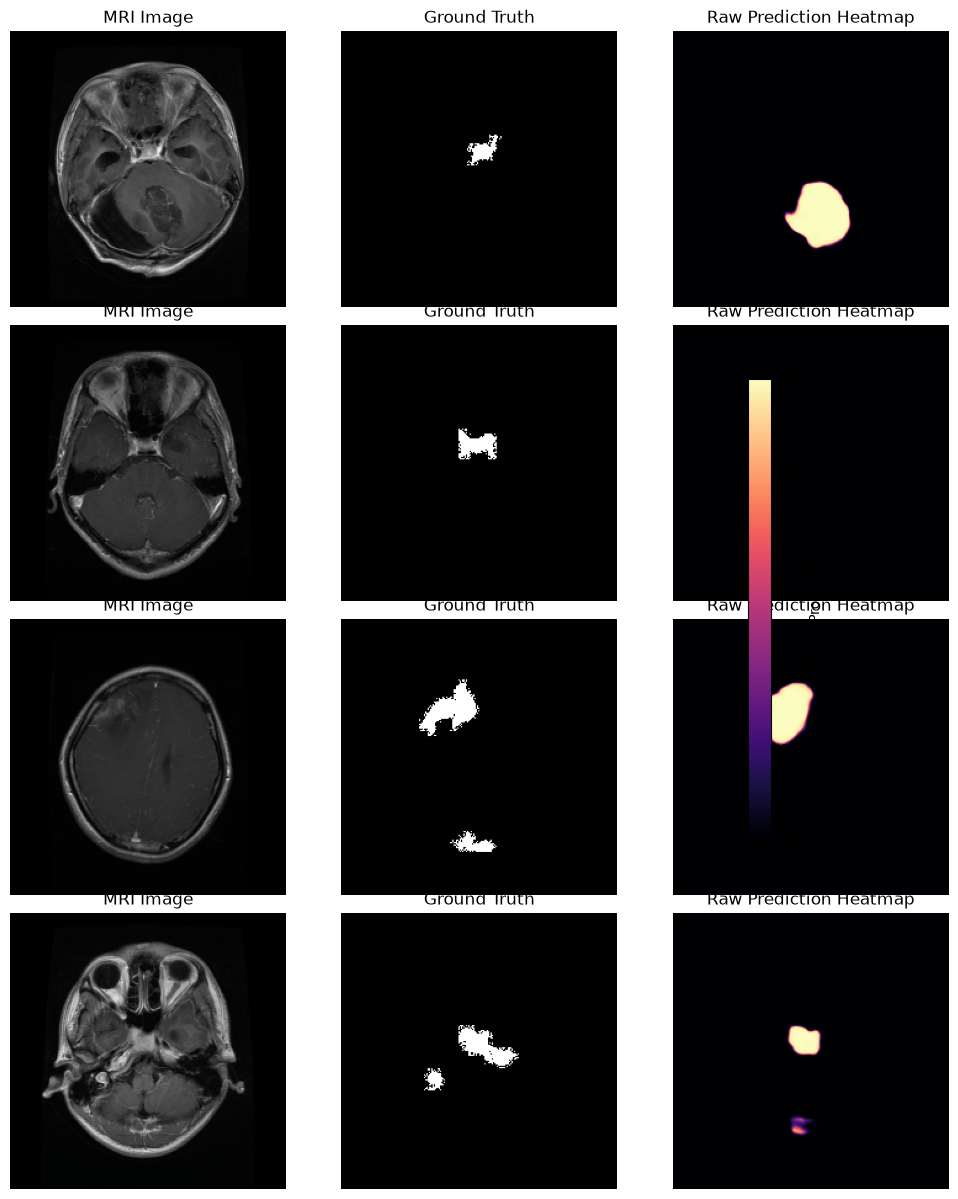

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    image, mask = next(iter(test_loader))
    image, mask = image.to(device), mask.to(device).float()
    
    with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
        output = model(image)
    
    # DO NOT THRESHOLD YET. Just get the raw probabilities (0.0 to 1.0)
    raw_probs = torch.sigmoid(output)

n = 4
fig, axes = plt.subplots(n, 3, figsize=(10, 3*n))

for i in range(n):
    img_np = image[i].cpu().permute(1,2,0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = img_np.clip(0, 1)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title('MRI Image')
    
    axes[i,1].imshow(mask[i,0].cpu(), cmap='gray')
    axes[i,1].set_title('Ground Truth')
    
    # PLOT THE HEATMAP
    # Index [i, 0] isolates the single probability channel as a 2D matrix
    prob_map = raw_probs[i, 0].cpu().numpy()
    
    # 'magma' colormap: Black=0% confident, Yellow/White=100% confident
    im = axes[i,2].imshow(prob_map, cmap='magma', vmin=0, vmax=1)
    axes[i,2].set_title('Raw Prediction Heatmap')
    
    for ax in axes[i]:
        ax.axis('off')

# Add a colorbar so you can read the confidence levels
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5, label='Tumor Probability')
plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
torch.cuda.empty_cache()